<a href="https://colab.research.google.com/github/sanjanascorner/PyTorch-and-DeepLearning/blob/main/UNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from glob import glob

class DriveDataset(Dataset):
    def __init__(self,image_paths,mask_paths):
        self.image_paths=image_paths
        self.mask_paths=mask_paths
        self.transform=transforms.Compose([
            transforms.Resize((512,512)),
            transforms.ToTensor()
        ])
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self,idx):
        image_path=self.image_paths[idx]
        mask_path=self.mask_paths[idx]
        image=Image.open(image_path).convert("RGB")
        mask=Image.open(mask_path).convert("L")
        image=self.transform(image)
        mask=self.transform(mask)
        mask=(mask>0.5).float()
        return image,mask


In [ ]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("/content/drive")

Images:20
Masks:20


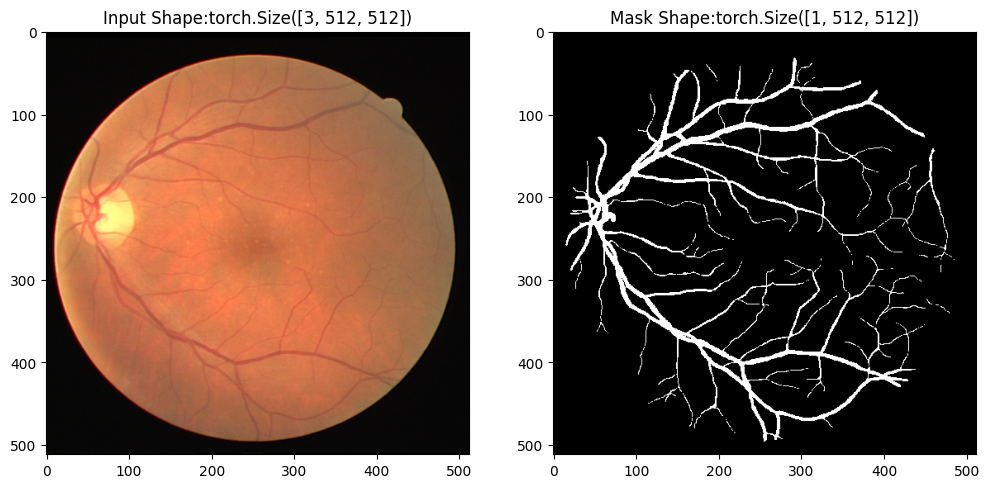

In [ ]:
import os
import matplotlib.pyplot as plt
input_dir='/content/drive'
train_x=[]
train_y=[]
for root,dirs,files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith(('.tif','.png','.jpg')) and 'training' in root and 'images' in root:
           train_x.append(os.path.join(root,file))
        elif file.lower().endswith(('.gif','.png','.tif')) and 'training' in root and '1st_manual' in root:
              train_y.append(os.path.join(root,file))
#sorting images and mask data
train_x=sorted(train_x)
train_y=sorted(train_y)
print(f"Images:{len(train_x)}")
print(f"Masks:{len(train_y)}")
if len(train_x)>0:
   train_dataset=DriveDataset(train_x,train_y)
   image,mask=train_dataset[0] #first image of train dataset has been plotted
   image_np=image.permute(1,2,0).numpy()
   mask_np=mask.squeeze().numpy()

   plt.figure(figsize=(12,6))
   plt.subplot(1,2,1)
   plt.title(f"Input Shape:{image.shape}")
   plt.imshow(image_np)
   plt.subplot(1,2,2)
   plt.title(f"Mask Shape:{mask.shape}")
   plt.imshow(mask_np,cmap="gray")
   plt.show()
else:
   print("check if dataset finished downloading")

In [ ]:
from sklearn.model_selection import train_test_split

if len(train_x) > 0:
    train_img, val_img, train_mask, val_mask = train_test_split(
        train_x, train_y, test_size=0.2, random_state=42
    )
    train_dataset = DriveDataset(train_img, train_mask)
    val_dataset = DriveDataset(val_img, val_mask)
    train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
else:
    print("Please verify your input directory and ensure files exist.")

Training samples: 16
Validation samples: 4


U-Net Architecture

In [ ]:
import torch
import torch.nn as nn
class DoubleConv(nn.Module):
    def __init__(self,in_channels,out_channels):
        super(DoubleConv,self).__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels,out_channels,kernel_size=3,padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self,x):
        return self.conv(x)
class UNet(nn.Module):
    def __init__(self,in_channels=3,out_channels=1):
        super(UNet,self).__init__()
        #Encoder
        self.down1=DoubleConv(in_channels,64)
        self.down2=DoubleConv(64,128)
        self.down3=DoubleConv(128,256)
        self.down4=DoubleConv(256,512)
        self.pool=nn.MaxPool2d(kernel_size=2,stride=2)
        #Bottleneck
        self.bottleneck=DoubleConv(512,1024)
        #Decoder
        self.upconv4=nn.ConvTranspose2d(1024,512,kernel_size=2,stride=2)
        self.up4=DoubleConv(1024,512)
        self.upconv3=nn.ConvTranspose2d(512,256,kernel_size=2,stride=2)
        self.up3=DoubleConv(512,256)
        self.upconv2=nn.ConvTranspose2d(256,128,kernel_size=2,stride=2)
        self.up2=DoubleConv(256,128)
        self.upconv1=nn.ConvTranspose2d(128,64,kernel_size=2,stride=2)
        self.up1=DoubleConv(128,64)
        #Final Layer
        self.outconv=nn.Conv2d(64,out_channels,kernel_size=1) #1x1 conv to reduce channels to our desired number of classes
    def forward(self,x):
        d1=self.down1(x)
        x=self.pool(d1)
        d2=self.down2(x)
        x=self.pool(d2)
        d3=self.down3(x)
        x=self.pool(d3)
        d4=self.down4(x)
        x=self.pool(d4)
        x=self.bottleneck(x)
        x=self.upconv4(x)
        x=torch.cat((x,d4),dim=1) #skip connection
        x=self.up4(x)
        x=self.upconv3(x)
        x=torch.cat((x,d3),dim=1)
        x=self.up3(x)
        x=self.upconv2(x)
        x=torch.cat((x,d2),dim=1)
        x=self.up2(x)
        x=self.upconv1(x)
        x=torch.cat((x,d1),dim=1)
        x=self.up1(x)
        return self.outconv(x)



In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader
train_loader=DataLoader(train_dataset,batch_size=2,shuffle=True)
device=torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(f"Training on device:{device}")
model=UNet(in_channels=3,out_channels=1).to(device)
criterion=nn.BCEWithLogitsLoss()
optimizer=optim.Adam(model.parameters(),lr=1e-4)
num_epochs=10
print("starting the training")
for epoch in range(num_epochs):
    model.train()
    epoch_loss=0
    for images,masks in train_loader:
        images=images.to(device)
        masks=masks.to(device)
        outputs=model(images)
        loss=criterion(outputs,masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss+=loss.item()
    avg_loss=epoch_loss/len(train_loader)
    print(f"Epoch:[{epoch+1}/{num_epochs}],Loss:{avg_loss:.4f}")


Training on device:cuda
starting the training
Epoch:[1/10],Loss:0.4557
Epoch:[2/10],Loss:0.3838
Epoch:[3/10],Loss:0.3428
Epoch:[4/10],Loss:0.3138
Epoch:[5/10],Loss:0.2947
Epoch:[6/10],Loss:0.2800
Epoch:[7/10],Loss:0.2687
Epoch:[8/10],Loss:0.2594
Epoch:[9/10],Loss:0.2528
Epoch:[10/10],Loss:0.2496


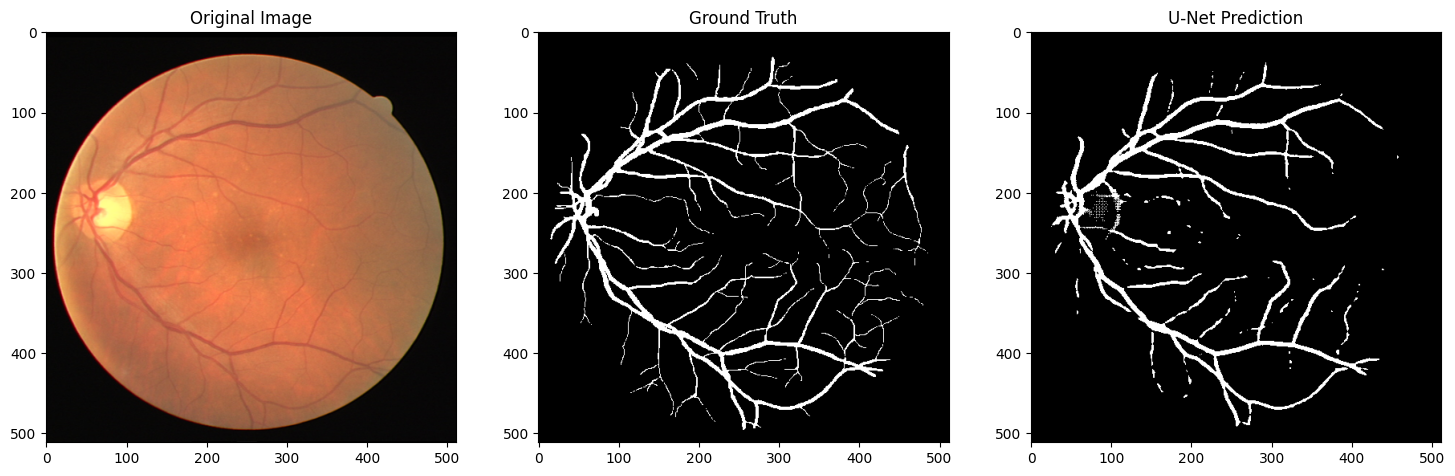

In [ ]:
model.eval()
images, masks = next(iter(val_loader))
images = images.to(device)
with torch.no_grad():
    raw_predictions = model(images)
    probs = torch.sigmoid(raw_predictions)
    binary_preds = (probs > 0.5).float()

original_img = images[0].cpu().permute(1, 2, 0).numpy()
ground_truth = masks[0].cpu().squeeze().numpy()
unet_pred = binary_preds[0].cpu().squeeze().numpy()

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(original_img)

plt.subplot(1, 3, 2)
plt.title("Ground Truth")
plt.imshow(ground_truth, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("U-Net Prediction")
plt.imshow(unet_pred, cmap='gray')

plt.show()

Test Images found: 20


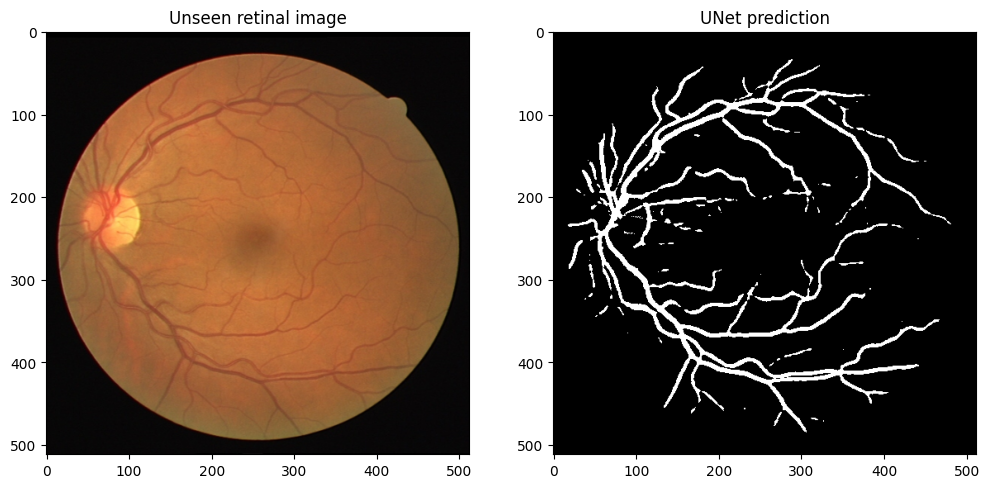

In [ ]:
from PIL import Image
from torchvision import transforms
test_x=[]
for root,dirs,files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith(('.tif','.png','.jpg')) and 'test' in root and 'images' in root:
           test_x.append(os.path.join(root,file))
test_x=sorted(test_x)
print(f"Test Images found: {len(test_x)}")
if len(test_x)>0:
   test_img_path=test_x[0]
   raw_img=Image.open(test_img_path).convert("RGB")
   transform=transforms.Compose([
        transforms.Resize((512,512)),
        transforms.ToTensor()
   ])
   input_tensor=transform(raw_img).unsqueeze(0).to(device)
   with torch.no_grad():
        raw_pred=model(input_tensor)
        prob_pred=torch.sigmoid(raw_pred)
        binary_pred=(prob_pred>0.5).float()
   display_img=input_tensor[0].cpu().permute(1,2,0).numpy()
   display_pred=binary_pred[0].cpu().squeeze().numpy()
   plt.figure(figsize=(12,6))
   plt.subplot(1,2,1)
   plt.title("Unseen retinal image")
   plt.imshow(display_img)
   plt.subplot(1,2,2)
   plt.title("UNet prediction")
   plt.imshow(display_pred,cmap="gray")
   plt.show()
else:
   print("Couldn't find test images")